In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/shivsrijitverma/grayimgdata/texturedImg.jpg
/kaggle/input/datasets/shivsrijitverma/grayimgdata/grayscaleImg.jpg
/kaggle/input/datasets/shivsrijitverma/grayimgdata/smooth.jpg


In [2]:
import cv2 
import matplotlib.pyplot as plt

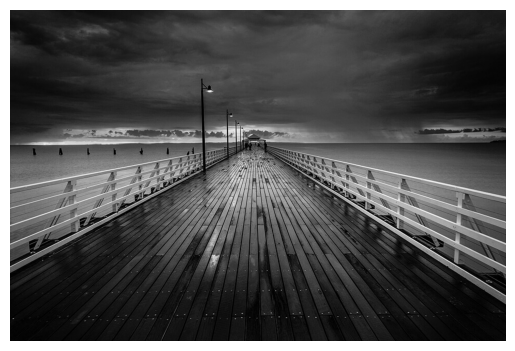

In [3]:
img = cv2.imread("/kaggle/input/datasets/shivsrijitverma/grayimgdata/grayscaleImg.jpg", cv2.IMREAD_GRAYSCALE)
plt.imshow(img, cmap = "gray")
plt.axis("off")
plt.show()

In [4]:
#first order derivative 
gx = cv2.Sobel(img, cv2.CV_64F, 1, 0 , ksize=3)
gy = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)

abs_gx = np.absolute(gx)
abs_gy = np.absolute(gy)
gradient_mag = cv2.addWeighted(abs_gx, 0.5, abs_gy, 0.5, 0)

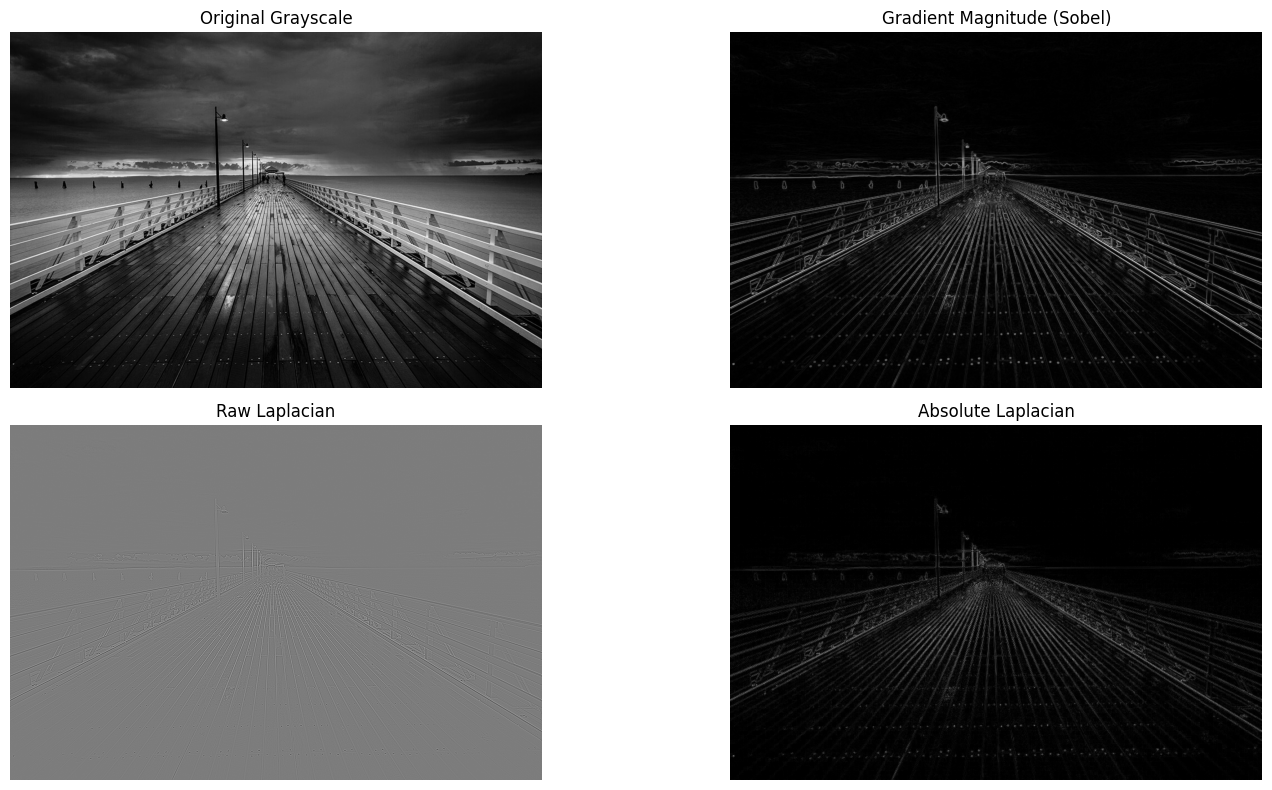

In [5]:
#second order derivative
laplacian = cv2.Laplacian(img, cv2.CV_64F)
abs_laplacian = np.absolute(laplacian)

titles = ['Original Grayscale', 'Gradient Magnitude (Sobel)', 
              'Raw Laplacian', 'Absolute Laplacian']
images = [img, gradient_mag, laplacian, abs_laplacian]

plt.figure(figsize=(16,8))
for i in range(4):
    plt.subplot(2,2,i+1)
    plt.imshow(images[i], cmap="gray")
    plt.title(titles[i])
    plt.axis('off')

plt.tight_layout()
plt.show()

#### f) Compare Gradient Magnitude vs. Absolute Laplacian 
Observation: The Sobel gradient image shows thicker, more prominent edges. The Absolute Laplacian shows much finer, thinner lines and often looks "noisier" with many tiny white dots.

Inference: First-order derivatives (Sobel) are better at detecting the presence of an edge and are more robust against noise. Second-order derivatives (Laplacian) are better at pinpointing the exact location and fine details but are very sensitive to noise.

#### g) Compare Raw Laplacian vs. Absolute Laplacian 
Observation: The Raw Laplacian appears mostly gray, with edges appearing as a "double line" (one side light, one side dark). The Absolute Laplacian shows white edges on a black background.

Inference: The Raw Laplacian preserves the direction of the transition (dark-to-light vs. light-to-dark). The point where the pixel value crosses from positive to negative in the raw image is the Zero-Crossing, which marks the center of the edge. The absolute value is used primarily for better human visualization of the edge map.

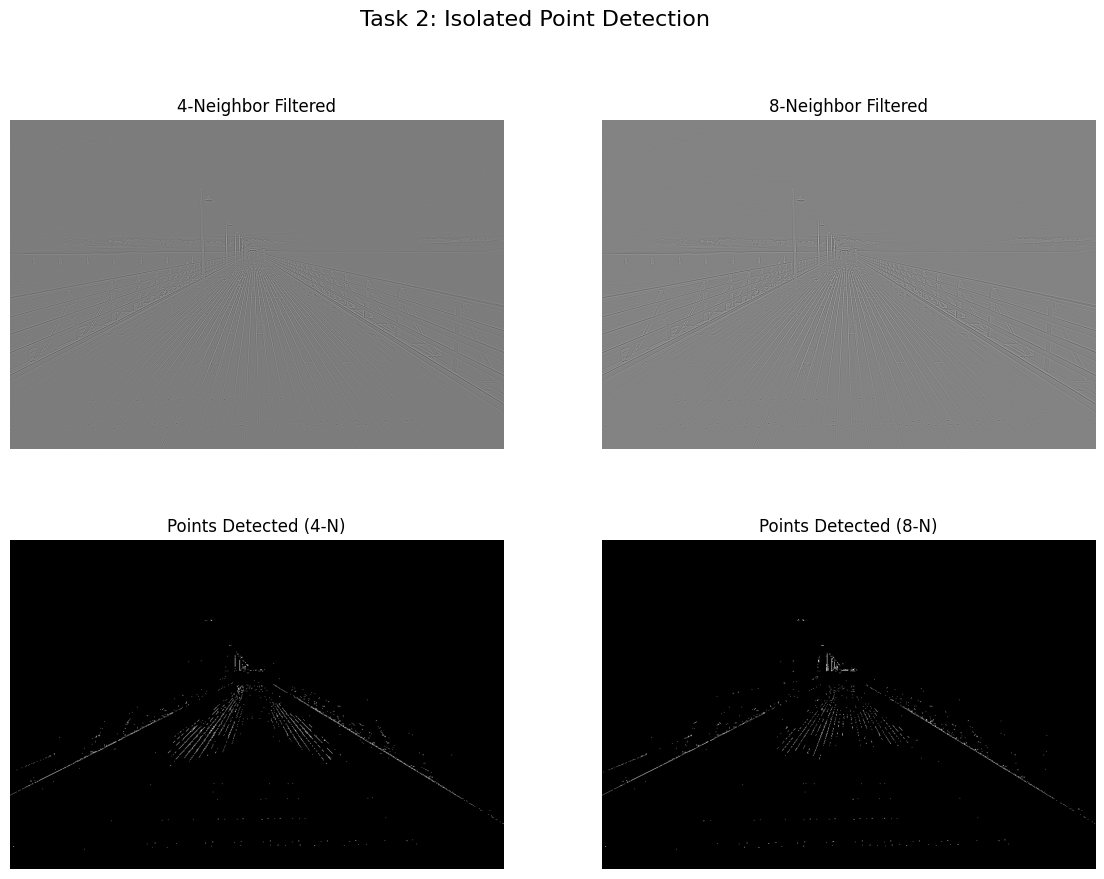

In [6]:
#Isolated point detection 
#kernel1 : 4neighbour
kernel1 = np.array([[0,1,0], [1,-4,1],[0,1,0]], dtype = np.float32)

#kernel2 : 8neighbour 
kernel2 = np.array([[1, 1, 1], [1, -8, 1], [1, 1, 1]], dtype=np.float32)

f1 = cv2.filter2D(img, cv2.CV_64F, kernel1)
f2 = cv2.filter2D(img, cv2.CV_64F, kernel2)

# We use 40% of the max intensity to isolate the most prominent "point"

def get_thresholded(filtered_img, sensitivity = 0.4):
    abs_img = np.absolute(filtered_img)
    thresh_val = sensitivity * np.max(abs_img)
    _, result = cv2.threshold(abs_img, thresh_val , 255, cv2.THRESH_BINARY)
    return result 


pts_f1 = get_thresholded(f1)
pts_f2 = get_thresholded(f2)

plt.figure(figsize=(14, 10))
plt.suptitle("Task 2: Isolated Point Detection", fontsize=16)
    
point_images = [f1, f2, pts_f1, pts_f2]
point_titles = ['4-Neighbor Filtered', '8-Neighbor Filtered', 
                    'Points Detected (4-N)', 'Points Detected (8-N)']
    
for i in range(4):
    plt.subplot(2, 2, i+1)
    plt.imshow(point_images[i], cmap='gray')
    plt.title(point_titles[i])
    plt.axis('off')
plt.show()

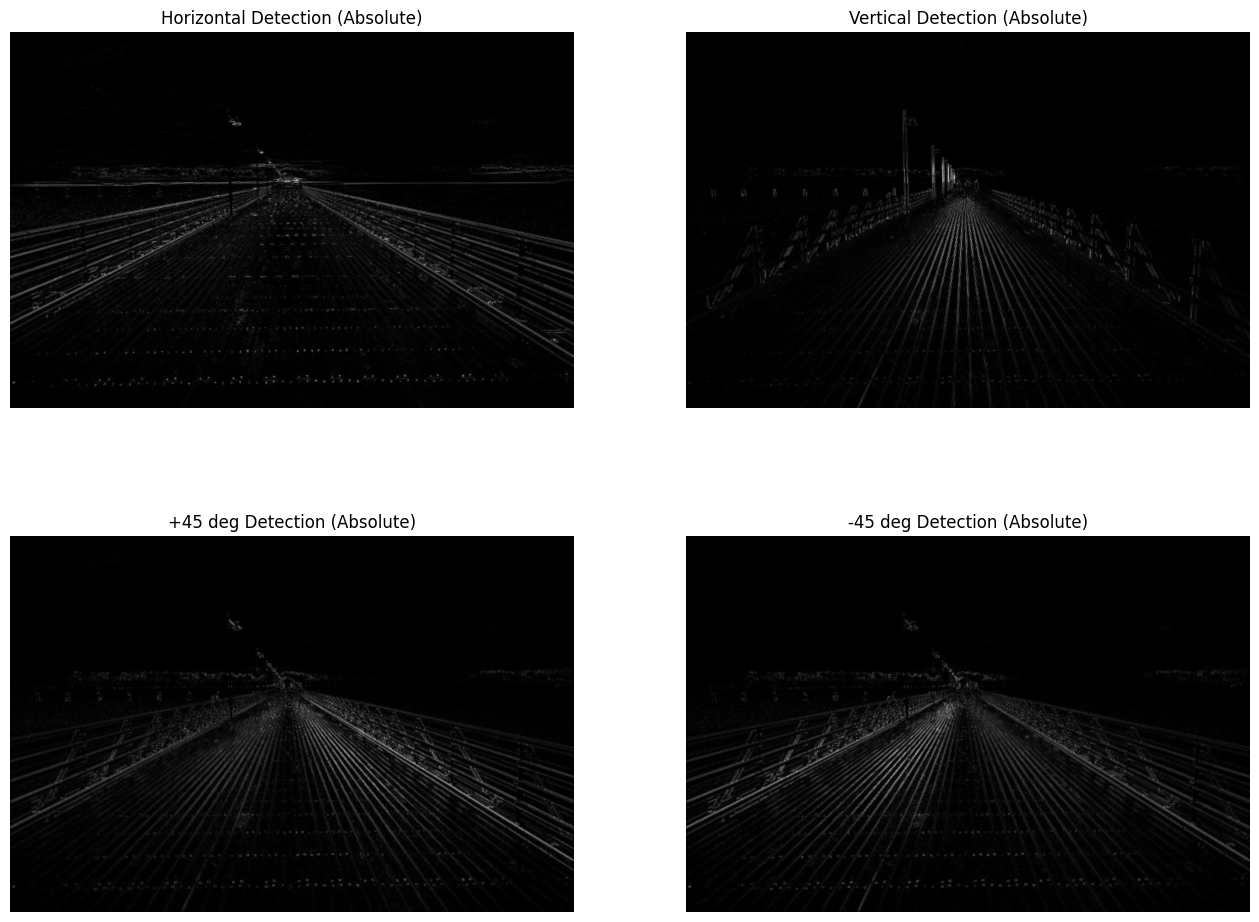

In [7]:
#Line Detection 
h_mask = np.array([[-1, -1, -1], [ 2,  2,  2], [-1, -1, -1]])
v_mask = np.array([[-1,  2, -1], [-1,  2, -1], [-1,  2, -1]])
d1_mask = np.array([[ 2, -1, -1], [-1,  2, -1], [-1, -1,  2]]) 
d2_mask = np.array([[-1, -1,  2], [-1,  2, -1], [ 2, -1, -1]])

masks = [h_mask, v_mask, d1_mask, d2_mask]
titles = ['Horizontal', 'Vertical', '+45 deg', '-45 deg']

filtered_images = [cv2.filter2D(img, cv2.CV_64F, m) for m in masks]

clamped_images = [np.maximum(0, img_f) for img_f in filtered_images]

abs_images = [np.absolute(img_f) for img_f in filtered_images]

plt.figure(figsize=(16, 12))
for i in range(4):
    plt.subplot(2, 2, i+1)
    plt.imshow(abs_images[i], cmap='gray')
    plt.title(f"{titles[i]} Detection (Absolute)")
    plt.axis('off')
plt.show()



### Inferences 
- Directional Selectivity: Each mask is highly specialized. The Horizontal mask will almost completely ignore vertical lines. This allows for "feature isolation"—if you only want to find the lanes on a road or the bricks in a wall, you pick the corresponding mask.
- Response Strength: The strongest response occurs when the line in the image perfectly aligns with the "2s" in the mask. If a line is at $20^\circ$, it will show up weakly in both the Horizontal ($0^\circ$) and Diagonal ($45^\circ$) results.
- Clamping vs. Absolute: Clamping (setting negatives to 0) is a form of non-linear filtering that simplifies the image by removing "inverse" edges. Absolute value provides a more complete map of all physical discontinuities.

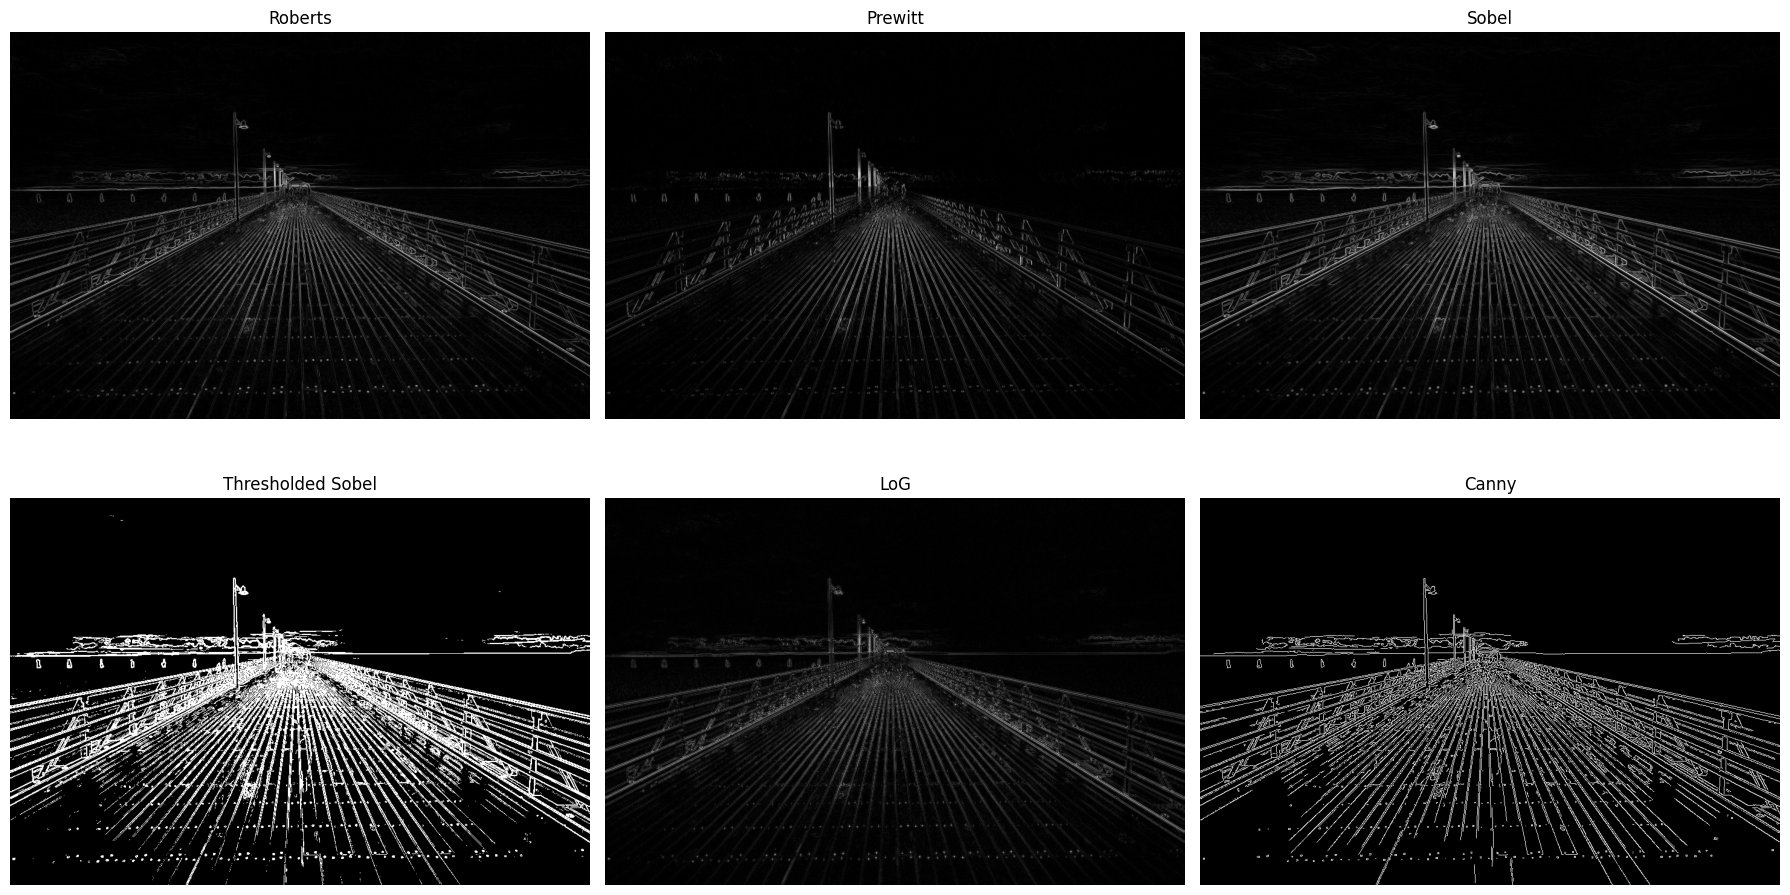

In [8]:
# Edge Detection 

#Sobel 
sx = cv2.Sobel(img, cv2.CV_64F, 1 , 0 , ksize=3)
sy = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)
sobel = cv2.magnitude(sx, sy)

#Prewitt
px_k = np.array([[-1, 0, 1], [-1, 0, 1], [-1, 0, 1]])
py_k = np.array([[-1, -1, -1], [0, 0, 0], [1, 1, 1]])

px = cv2.filter2D(img , cv2.CV_64F, px_k)
py = cv2.filter2D(img, cv2.CV_64F, px_k)
prewitt = cv2.magnitude(px,py)

#Roberts
rx_k = np.array([[1, 0], [0, -1]])
ry_k = np.array([[0, 1], [-1, 0]])
rx = cv2.filter2D(img, cv2.CV_64F, rx_k)
ry = cv2.filter2D(img, cv2.CV_64F, ry_k)
roberts = cv2.magnitude(rx, ry)

#Thresholding (on sobel):
_, thresh_sobel = cv2.threshold(sobel, 100, 255, cv2.THRESH_BINARY)

#Laplacian 
blur = cv2.GaussianBlur(img , (3,3) , 0 )
log = cv2.Laplacian(blur, cv2.CV_64F)

#Canny 
canny = cv2.Canny(img , 100, 200) # (image, low_thresh, high_thresh)

titles = ['Roberts', 'Prewitt', 'Sobel', 'Thresholded Sobel', 'LoG', 'Canny']
images = [roberts, prewitt, sobel, thresh_sobel, np.absolute(log), canny]

plt.figure(figsize=(18, 10))
for i in range(6):
    plt.subplot(2, 3, i+1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')
plt.tight_layout()
plt.show()

#### Inferences
- Roberts vs. Sobel: You will notice Roberts is "grainy" (noisy) while Sobel is much smoother and clearer.

- Thresholding Inference: Without thresholding, you see "gradient strength" (fuzzy lines). After thresholding, you get a binary "Edge Map".

- LoG Inference: It detects edges by looking for Zero-Crossings. It's great for thin edges but can create "false loops" in noisy areas.

- Canny Inference: Canny will provide the cleanest, thinnest lines. While Sobel edges might be 3-5 pixels wide, Canny uses "Non-Maximum Suppression" to ensure edges are exactly 1 pixel wide.

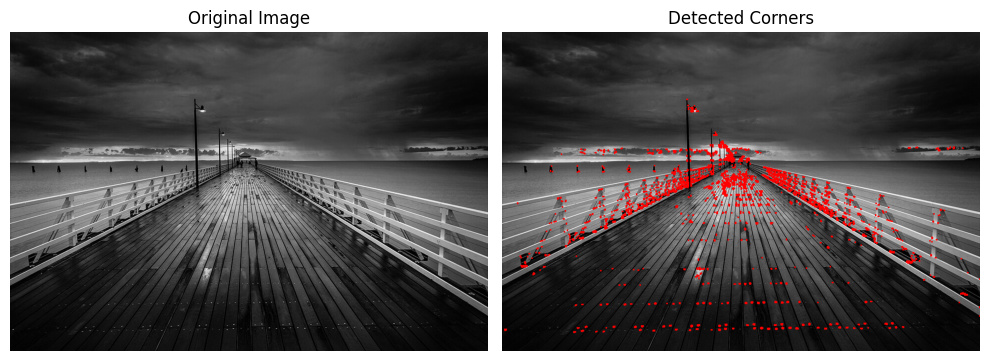

In [16]:
# Harris Algorithm

img = cv2.imread('/kaggle/input/datasets/shivsrijitverma/grayimgdata/grayscaleImg.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)  #converting img to grayscale
gray = np.float32(gray) #converting to float32

#applying harris corner detection 
# Parameters: (image, blockSize, ksize, k)
# blockSize: size of neighbourhood considered for corner detection
# ksize: Aperture parameter of Sobel derivative used
# k: Harris detector free parameter in the equation

dst = cv2.cornerHarris(gray, 2, 3, 0.05)

# Result is dilated for marking the corners (purely for visualization)
dst = cv2.dilate(dst, None)

# We mark the corners in red on the original image
img[dst > 0.01 * dst.max()] = [0, 0, 255]

# Display Results
plt.figure(figsize=(10, 6))
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(cv2.imread('/kaggle/input/datasets/shivsrijitverma/grayimgdata/grayscaleImg.jpg'), cv2.COLOR_BGR2RGB))
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title('Detected Corners')
plt.axis('off')

plt.tight_layout()
plt.show()




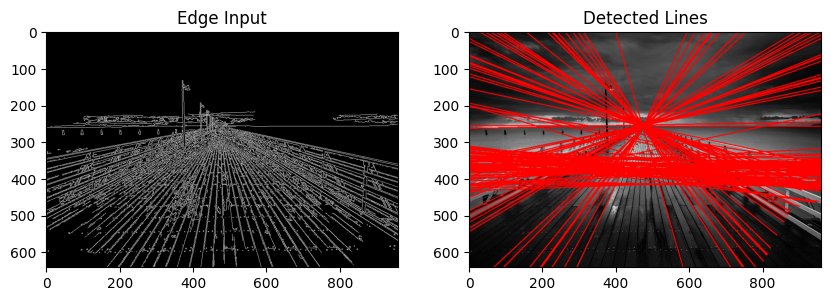

In [44]:
# Hough Transform 
img = cv2.imread('/kaggle/input/datasets/shivsrijitverma/grayimgdata/grayscaleImg.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
edges = cv2.Canny(gray, 50, 150, apertureSize=3)

# b) Apply Hough Transform
# Parameters: (image, rho_resolution, theta_resolution, threshold)
# rho: 1 pixel accuracy
# theta: np.pi/180 (1 degree accuracy)
# threshold: minimum votes to be considered a line
lines = cv2.HoughLines(edges, 1, np.pi/180, 250)

# c) Draw the lines on the original image
if lines is not None:
    for line in lines:
        rho, theta = line[0]
        a = np.cos(theta)
        b = np.sin(theta)
        x0 = a * rho
        y0 = b * rho
        # Extend the line for visualization
        x1 = int(x0 + 1000 * (-b))
        y1 = int(y0 + 1000 * (a))
        x2 = int(x0 - 1000 * (-b))
        y2 = int(y0 - 1000 * (a))
        cv2.line(img, (x1, y1), (x2, y2), (0, 0, 255), 2)

# Display Results
plt.figure(figsize=(10, 6))
plt.subplot(1, 2, 1)
plt.imshow(edges, cmap='gray')
plt.title('Edge Input')
plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title('Detected Lines')
plt.show()